# Lib

In [1]:
!pip -q install --no-input opencv-python-headless==4.10.0.84 tqdm==4.66.4 imageio==2.35.1
!pip -q install --no-input simple-lama-inpainting==0.1.2
!pip -q install --no-input gfpgan==1.3.8 basicsr==1.4.2 facexlib==0.3.0 realesrgan==0.3.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 34.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.4/315.4 kB 17.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 3.6.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2025.5.1 which is incompatible.
preprocessing 0.1.13 requires nltk==3.2.4, but you have nltk 3.9.1 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
dataproc-spark-connect 0.7.5 requires google-api-core>=2.19, but you have google-api-core 1.34.1 which is incompatible.
dataproc-spark-connect 0.7.5 requires tqdm>=4.67, but you have tqdm 4.66.4 wh

In [2]:
import os, glob, cv2, numpy as np
from pathlib import Path

In [3]:
paths = [
    '/kaggle/input/flickr-faces-hq/00000',
    '/kaggle/input/flickr-faces-hq-2/01000',
    '/kaggle/input/flickr-faces-hq-3/02000',
    '/kaggle/input/flickr-faces-hq-4/03000',
    '/kaggle/input/flickr-faces-hq-5/04000',
    '/kaggle/input/flickr-faces-hq-6/05000',
    '/kaggle/input/flickr-faces-hq-7/06000'
]
DATA_DIR  = '/kaggle/working/all_images'
SIZE      = 256
LIMIT     = None
TEST_DIR  = '/kaggle/input/testdata'

In [4]:
IMG_DIR  = os.path.join(DATA_DIR, 'images')
OUT_DIR  = '/kaggle/working/outputs'
CKPT_DIR = '/kaggle/working/checkpoints'
for d in [DATA_DIR, IMG_DIR, OUT_DIR, CKPT_DIR]:
    os.makedirs(d, exist_ok=True)
print("READY: DATA_DIR=", DATA_DIR)

READY: DATA_DIR= /kaggle/working/all_images


# Chuẩn bị dữ liệu: gom ảnh

In [5]:
import cv2, traceback
from tqdm.auto import tqdm

In [6]:
def is_image_file(p: Path):
    return p.suffix.lower() in {'.jpg','.jpeg','.png','.bmp','.webp'}

In [7]:
def gather_images(src_paths, img_dir, limit=None, resize=None):
    pths = []
    for sp in src_paths:
        p = Path(sp)
        if not p.exists():
            print(f"[WARN] Not found: {sp}")
            continue
        for f in p.iterdir():
            if is_image_file(f):
                pths.append(f)
    if limit is not None:
        pths = pths[:int(limit)]
    print(f"Found {len(pths)} images.")

    count = 0
    for f in tqdm(pths, desc="Copying"):
        try:
            img = cv2.imread(str(f))
            if img is None: continue
            if resize is not None:
                img = cv2.resize(img, resize, interpolation=cv2.INTER_AREA)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            out_path = Path(img_dir)/f"{count:06d}.png"
            cv2.imwrite(str(out_path), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
            count += 1
        except Exception:
            print("Skip:", f, "\n", traceback.format_exc())
    print("Gathered:", count)
    return count

In [8]:
N = gather_images(paths, IMG_DIR, limit=LIMIT, resize=None)
print("Total images collected:", N)

Found 7000 images.


Copying:   0%|          | 0/7000 [00:00<?, ?it/s]

Gathered: 7000
Total images collected: 7000


# Dataset + DataLoader

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np, cv2, glob, os
from pathlib import Path

In [10]:
def to_tensor_img(img_np):
    return torch.from_numpy((img_np.astype(np.float32)/127.5 - 1.0)).permute(2,0,1)

In [11]:
def resize_longest_maxsize_and_pad(img, size=256):
    h, w = img.shape[:2]
    if h == 0 or w == 0:
        return np.zeros((size, size, 3), np.uint8)
    scale = size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    interp = cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC
    resized = cv2.resize(img, (new_w, new_h), interpolation=interp)
    top = (size - new_h) // 2; bottom = size - new_h - top
    left = (size - new_w) // 2; right  = size - new_w - left
    return cv2.copyMakeBorder(resized, top, bottom, left, right, cv2.BORDER_REFLECT_101)

In [12]:

def random_white_box_mask(h, w, min_frac=0.12, max_frac=0.28, center_bias=0.15):
    """
    Create ONE solid white rectangular mask (255) like the samples.
    - min_frac/max_frac: range of masked AREA fraction relative to the whole image
    - center_bias: probability mass to keep the rectangle near the face center
    Returns: uint8 mask in [0,255], shape (h,w)
    """
    m = np.zeros((h, w), np.uint8)
    area = h * w
    # Choose area for the rectangle
    target = np.random.uniform(min_frac, max_frac) * area
    # Sample aspect ratio around 1.6 (typical mouth/eye box) but keep flexible
    aspect = np.exp(np.random.uniform(np.log(0.8), np.log(2.2)))
    rw = int(np.sqrt(target * aspect))
    rh = int(max(1, target // max(rw,1)))
    # Clamp to image bounds
    rw = int(np.clip(rw, max(8, w//12), w-2))
    rh = int(np.clip(rh, max(8, h//12), h-2))

    # Bias center to the middle region (face) with some randomness
    cx_lo = int(w*(0.35-center_bias)); cx_hi = int(w*(0.65+center_bias))
    cy_lo = int(h*(0.35-center_bias)); cy_hi = int(h*(0.65+center_bias))
    cx = np.random.randint(max(0, cx_lo), min(w-1, cx_hi)) if np.random.rand()<0.85 else np.random.randint(0, w)
    cy = np.random.randint(max(0, cy_lo), min(h-1, cy_hi)) if np.random.rand()<0.85 else np.random.randint(0, h)

    x1 = int(np.clip(cx - rw//2, 0, w-1))
    y1 = int(np.clip(cy - rh//2, 0, h-1))
    x2 = int(np.clip(x1 + rw, 1, w))
    y2 = int(np.clip(y1 + rh, 1, h))
    cv2.rectangle(m, (x1,y1), (x2,y2), 255, -1)

    return m

# Backward-compatible alias to keep the training code unchanged
random_brush_mask = random_white_box_mask

In [13]:
def occ_blend(img, mask):
    occ = img.copy()
    if np.random.rand() < 0.5:
        color = np.uint8(np.random.randint(0,256, size=(1,1,3)))
        occ[mask>0] = (0.6*occ[mask>0] + 0.4*color).astype(np.uint8)
    else:
        noise = np.clip(np.random.randn(*occ.shape)*30 + 128, 0, 255).astype(np.uint8)
        occ[mask>0] = noise[mask>0]
    return occ

In [14]:
class FaceOccDataset(Dataset):
    def __init__(self, img_dir, size=256):
        self.paths = sorted([p for p in Path(img_dir).glob("*.png")])
        self.size = size
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        p = self.paths[idx]
        img = cv2.imread(str(p))
        if img is None:
            img = np.zeros((self.size, self.size, 3), np.uint8)
        else:
            img = img[:, :, ::-1]
        img = resize_longest_maxsize_and_pad(img, size=self.size)
        m = random_brush_mask(self.size, self.size)
        occ = occ_blend(img, m)
        return {
            'img':  to_tensor_img(img),
            'occ':  to_tensor_img(occ),
            'mask': torch.from_numpy((m>127).astype(np.float32))[None],
            'path': str(p)
        }

In [15]:
BATCH_SIZE = 8

In [16]:
train_ds = FaceOccDataset(IMG_DIR, size=SIZE)
val_ds   = FaceOccDataset(IMG_DIR, size=SIZE)

In [17]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print("Train/Val:", len(train_ds), len(val_ds))

Train/Val: 7000 7000


# MaskNet (UNet nhỏ) + Dice Loss + EMA

In [18]:
import torch, torch.nn as nn, torch.nn.functional as F

In [19]:
class DoubleConv(nn.Module):
    def __init__(self,c_in,c_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in,c_out,3,1,1), nn.BatchNorm2d(c_out), nn.ReLU(True),
            nn.Conv2d(c_out,c_out,3,1,1), nn.BatchNorm2d(c_out), nn.ReLU(True),
        )
    def forward(self,x): return self.net(x)

In [20]:
class UNetSmall(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, ch=32):
        super().__init__()
        self.d1=DoubleConv(in_ch, ch); self.p1=nn.MaxPool2d(2)
        self.d2=DoubleConv(ch, ch*2);  self.p2=nn.MaxPool2d(2)
        self.d3=DoubleConv(ch*2, ch*4);self.p3=nn.MaxPool2d(2)
        self.b =DoubleConv(ch*4, ch*8)
        self.u3=nn.ConvTranspose2d(ch*8, ch*4, 2,2); self.h3=DoubleConv(ch*8, ch*4)
        self.u2=nn.ConvTranspose2d(ch*4, ch*2, 2,2); self.h2=DoubleConv(ch*4, ch*2)
        self.u1=nn.ConvTranspose2d(ch*2, ch,   2,2); self.h1=DoubleConv(ch*2, ch)
        self.out=nn.Conv2d(ch, out_ch, 1)
    def forward(self,x):
        x1=self.d1(x); x1p=self.p1(x1)
        x2=self.d2(x1p); x2p=self.p2(x2)
        x3=self.d3(x2p); x3p=self.p3(x3)
        xb=self.b(x3p)
        x = self.u3(xb); x=self.h3(torch.cat([x, x3],1))
        x = self.u2(x);  x=self.h2(torch.cat([x, x2],1))
        x = self.u1(x);  x=self.h1(torch.cat([x, x1],1))
        return self.out(x)

In [21]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.param_shadow = {n: p.detach().clone() for n,p in model.named_parameters() if p.requires_grad}
        self.buff_shadow  = {n: b.detach().clone() for n,b in model.named_buffers() if torch.is_floating_point(b)}
    @torch.no_grad()
    def update(self, model):
        for n,p in model.named_parameters():
            if not p.requires_grad: continue
            self.param_shadow[n].mul_(self.decay).add_(p.detach(), alpha=1-self.decay)
        for n,b in model.named_buffers():
            if not torch.is_floating_point(b): continue
            self.buff_shadow[n].mul_(self.decay).add_(b.detach(), alpha=1-self.decay)
    @torch.no_grad()
    def copy_to(self, model):
        for n,p in model.named_parameters():
            if n in self.param_shadow:
                p.data.copy_(self.param_shadow[n])
        for n,b in model.named_buffers():
            if n in self.buff_shadow and torch.is_floating_point(b):
                b.data.copy_(self.buff_shadow[n])

In [22]:
def dice_loss(pred, target, eps=1e-6):
    num = 2*(pred*target).sum(dim=(2,3))
    den = pred.sum(dim=(2,3)) + target.sum(dim=(2,3)) + eps
    return (1-(num/den)).mean()

# Train MaskNet (AMP + checkpoint)

In [23]:
import torch, os
from tqdm.auto import tqdm

In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net = UNetSmall().to(device)
opt = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
ema = EMA(net, decay=0.999)

/tmp/ipykernel_36/1986687729.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [25]:
print(device)

cuda


In [26]:
EPOCHS= 22
best_iou= 0.0

In [27]:
def batch_iou(p, t, th=0.5):
    pbin = (p>th).float()
    inter = (pbin*t).sum(dim=(2,3))
    union = (pbin + t - pbin*t).sum(dim=(2,3)) + 1e-6
    return (inter/union).mean().item()

In [28]:
for ep in range(1, EPOCHS+1):
    net.train()
    pbar = tqdm(train_loader, desc=f"Train Ep{ep}")
    for batch in pbar:
        occ = batch['occ'].to(device)
        m   = batch['mask'].to(device)
        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            logits = net((occ+1)/2)
            bce    = torch.nn.functional.binary_cross_entropy_with_logits(logits, m)
            pm     = torch.sigmoid(logits)
            dsc    = dice_loss(pm, m)
            loss   = bce + dsc
        scaler.scale(loss).backward()
        scaler.step(opt); scaler.update()
        ema.update(net)
        pbar.set_postfix(loss=float(loss.detach().cpu()))
    # Eval
    net.eval(); miou=0.0; n=0
    with torch.no_grad():
        for batch in val_loader:
            occ = batch['occ'].to(device); m = batch['mask'].to(device)
            pm = torch.sigmoid(net((occ+1)/2))
            miou += batch_iou(pm, m); n+=1
    miou /= max(n,1)
    print(f"[Epoch {ep}] mIoU={miou:.4f}")
    if miou > best_iou:
        best_iou = miou
        os.makedirs(CKPT_DIR, exist_ok=True)
        torch.save(net.state_dict(), os.path.join(CKPT_DIR, 'masknet_best.pth'))
        ema_model = UNetSmall().to(device); ema.copy_to(ema_model)
        torch.save(ema_model.state_dict(), os.path.join(CKPT_DIR, 'masknet_best_ema.pth'))
        del ema_model
        print("Saved best to", CKPT_DIR)

Train Ep1:   0%|          | 0/875 [00:00<?, ?it/s]

[Epoch 1] mIoU=0.6955
Saved best to /kaggle/working/checkpoints


Train Ep2:   0%|          | 0/875 [00:00<?, ?it/s]

[Epoch 2] mIoU=0.8137
Saved best to /kaggle/working/checkpoints


Train Ep3:   0%|          | 0/875 [00:00<?, ?it/s]

...

[Epoch 20] mIoU=0.9810


Train Ep21:   0%|          | 0/875 [00:00<?, ?it/s]

[Epoch 21] mIoU=0.9822


Train Ep22:   0%|          | 0/875 [00:00<?, ?it/s]

[Epoch 22] mIoU=0.9790


# Inference: MaskNet → LaMa → GFPGAN

In [29]:
import os, cv2, urllib.request, numpy as np, types, sys, torchvision, torch
from pathlib import Path
from PIL import Image
import torchvision.transforms.functional as F_tvF

In [30]:
ft = types.ModuleType("torchvision.transforms.functional_tensor")
ft.rgb_to_grayscale = F_tvF.rgb_to_grayscale
sys.modules['torchvision.transforms.functional_tensor'] = ft
print("Torch:", torch.__version__, "| Torchvision:", torchvision.__version__, "| Shim OK")

Torch: 2.6.0+cu124 | Torchvision: 0.21.0+cu124 | Shim OK


In [31]:
masknet = UNetSmall().to(device).eval()
ckpt_ema = os.path.join(CKPT_DIR, 'masknet_best_ema.pth')
ckpt     = ckpt_ema if os.path.exists(ckpt_ema) else os.path.join(CKPT_DIR, 'masknet_best.pth')
if os.path.exists(ckpt):
    masknet.load_state_dict(torch.load(ckpt, map_location=device), strict=True)
    print("Loaded MaskNet:", ckpt)
else:
    print("[WARN] No MaskNet checkpoint found (demo weights).")

Loaded MaskNet: /kaggle/working/checkpoints/masknet_best_ema.pth


In [32]:
from simple_lama_inpainting import SimpleLama
lama = SimpleLama()

Downloading: "https://github.com/enesmsahin/simple-lama-inpainting/releases/download/v0.1.0/big-lama.pt" to /root/.cache/torch/hub/checkpoints/big-lama.pt
100%|██████████| 196M/196M [00:00<00:00, 259MB/s] 


In [33]:
from gfpgan import GFPGANer
MODEL_DIR  = "/kaggle/working/gfpgan_models"; os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_PATH = os.path.join(MODEL_DIR, "GFPGANv1.4.pth")
if not os.path.exists(MODEL_PATH):
    try:
        print("Downloading GFPGANv1.4.pth ...")
        urllib.request.urlretrieve(
            "https://github.com/TencentARC/GFPGAN/releases/download/v1.3.0/GFPGANv1.4.pth",
            MODEL_PATH
        )
    except Exception as e:
        print("Download failed:", e, "\nUpload the file manually to", MODEL_PATH)
restorer = GFPGANer(model_path=MODEL_PATH if os.path.exists(MODEL_PATH) else None,
                    upscale=1, arch="clean", channel_multiplier=2, bg_upsampler=None)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://github.com/xinntao/facexlib/releases/download/v0.1.0/detection_Resnet50_Final.pth" to /kaggle/working/gfpgan/weights/detection_Resnet50_Final.pth



100%|██████████| 104M/104M [00:00<00:00, 304MB/s] 


Downloading: "https://github.com/xinntao/facexlib/releases/download/v0.2.2/parsing_parsenet.pth" to /kaggle/working/gfpgan/weights/parsing_parsenet.pth



100%|██████████| 81.4M/81.4M [00:00<00:00, 253MB/s]


In [34]:
def resize_longest_maxsize_and_pad(img, size=256):
    h, w = img.shape[:2]
    if h == 0 or w == 0:
        return np.zeros((size, size, 3), np.uint8)
    scale = size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    interp = cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC
    resized = cv2.resize(img, (new_w, new_h), interpolation=interp)
    top = (size - new_h) // 2; bottom = size - new_h - top
    left = (size - new_w) // 2; right  = size - new_w - left
    return cv2.copyMakeBorder(resized, top, bottom, left, right, cv2.BORDER_REFLECT_101)

In [35]:
@torch.no_grad()
def predict_mask(img_rgb_uint8, net, th=0.35, size=SIZE):
    H, W = img_rgb_uint8.shape[:2]
    small = resize_longest_maxsize_and_pad(img_rgb_uint8, size=size)
    x = torch.from_numpy((small.astype(np.float32)/127.5 - 1.0)).permute(2,0,1).to(device)
    logits = net((x[None]+1)/2)[0,0]
    pm = torch.sigmoid(logits).float().cpu().numpy()  # [0,1]
    m_small = (pm>th).astype(np.uint8)*255
    m = cv2.resize(m_small, (W, H), interpolation=cv2.INTER_NEAREST)
    k = np.ones((3,3), np.uint8)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k)
    return m 

In [36]:
def fix_mask_polarity_for_lama(m_uint8, min_white=0.005, max_white=0.95):
    wr = (m_uint8 > 127).mean() if m_uint8.size > 0 else 0.0
    if wr < min_white or wr > max_white:
        return 255 - m_uint8, True, wr
    return m_uint8, False, wr

In [37]:
def detect_solid_color_mask(img_rgb_uint8, k=5, area_lo=0.003, area_hi=0.45):
    H,W = img_rgb_uint8.shape[:2]
    if H*W < 16: return None
    lab = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2LAB)
    X = lab.reshape(-1,3).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS+cv2.TERM_CRITERIA_MAX_ITER, 50, 0.5)
    _ret, labels, centers = cv2.kmeans(X, k, None, criteria, 1, cv2.KMEANS_PP_CENTERS)
    labels = labels.reshape(H,W)

    # gradient trên kênh L (độ sáng)
    L = lab[:,:,0]
    gx = cv2.Sobel(L, cv2.CV_32F, 1,0,ksize=3)
    gy = cv2.Sobel(L, cv2.CV_32F, 0,1,ksize=3)
    grad = cv2.magnitude(gx,gy)
    grad = cv2.GaussianBlur(grad, (5,5), 0)

    center = np.zeros((H,W), np.uint8)
    ch0, ch1 = int(H*0.2), int(H*0.8)
    cw0, cw1 = int(W*0.2), int(W*0.8)
    center[ch0:ch1, cw0:cw1] = 1

    best_mask=None; best_score=1e9
    for lab_id in range(k):
        m = (labels==lab_id).astype(np.uint8)
        area = m.mean()
        if not (area_lo <= area <= area_hi): 
            continue
        overlap = (m*center).sum() / (center.sum()+1e-6)
        if overlap < 0.02:  
            continue
        mean_grad = float((grad*(m>0)).sum() / (m.sum()+1e-6))
        if mean_grad < best_score:
            best_score = mean_grad
            best_mask = m

    if best_mask is None:
        return None
    k5 = np.ones((5,5), np.uint8)
    m = cv2.morphologyEx(best_mask.astype(np.uint8)*255, cv2.MORPH_OPEN, k5)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k5)
    return m

In [38]:
from functools import lru_cache
from simple_lama_inpainting import SimpleLama

@lru_cache(maxsize=1)
def _lama():
    return SimpleLama()

def inpaint_lama(img_rgb_uint8, mask_uint8_255):
    return np.array(_lama()(Image.fromarray(img_rgb_uint8), Image.fromarray(mask_uint8_255)))

In [39]:
def restore_gfpgan(img_rgb_uint8):
    _, _, restored = restorer.enhance(img_rgb_uint8[:, :, ::-1],
                                      has_aligned=False, only_center_face=False, paste_back=True)
    return restored[:, :, ::-1]

In [40]:
def process_image_path(in_path, out_path_mask=None, out_path_inp=None, out_path_rest=None,
                       out_path_mask_raw=None, out_path_mask_solid=None):
    img = cv2.imread(in_path)
    if img is None: raise RuntimeError(f"Cannot read: {in_path}")
    img = img[:, :, ::-1]  # BGR->RGB

    m_pred = predict_mask(img, masknet, th=0.35, size=SIZE)

    m_solid = detect_solid_color_mask(img)
    if m_solid is not None and out_path_mask_solid:
        cv2.imwrite(out_path_mask_solid, m_solid)

    m_raw = np.maximum(m_pred, m_solid) if m_solid is not None else m_pred
    # Slight dilation to cover boundary for better inpainting
    k = np.ones((3,3), np.uint8)
    m_raw = cv2.dilate(m_raw, k, iterations=1)

    m_lama, inverted, wr = fix_mask_polarity_for_lama(m_raw, 0.005, 0.95)
    if out_path_mask_raw is not None: cv2.imwrite(out_path_mask_raw, m_raw)

    inp  = inpaint_lama(img, m_lama)
    rest = restore_gfpgan(inp)

    # 6) Lưu
    if out_path_mask is not None: cv2.imwrite(out_path_mask, m_lama)
    if out_path_inp  is not None: cv2.imwrite(out_path_inp,  cv2.cvtColor(inp,  cv2.COLOR_RGB2BGR))
    if out_path_rest is not None: cv2.imwrite(out_path_rest, cv2.cvtColor(rest, cv2.COLOR_RGB2BGR))
    return img, m_lama, inp, rest
print("Inference pipeline ready.")

Inference pipeline ready.


# Test

In [41]:
from tqdm.auto import tqdm
import os, cv2, numpy as np, glob
from pathlib import Path

In [42]:
def list_images(root):
    exts = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')
    return [p for p in glob.glob(os.path.join(root, '**', '*'), recursive=True)
            if p.lower().endswith(exts)]

In [43]:
INFER_SRC = TEST_DIR if os.path.exists(TEST_DIR) else IMG_DIR
print("INFER_SRC:", INFER_SRC)
os.makedirs(OUT_DIR, exist_ok=True)

INFER_SRC: /kaggle/input/testdata


In [44]:
def grid4(a,b,c,d):
    if b.ndim == 2: b3 = np.stack([b]*3, axis=-1)
    else: b3 = b
    H = min(a.shape[0], c.shape[0], d.shape[0], b3.shape[0])
    a  = cv2.resize(a,  (H, H)); b3 = cv2.resize(b3, (H, H))
    c  = cv2.resize(c,  (H, H)); d  = cv2.resize(d,  (H, H))
    return np.concatenate([a, b3, c, d], axis=1)

In [45]:
paths = sorted(list_images(INFER_SRC))
SAMPLE_MAX = None  
if SAMPLE_MAX is not None: paths = paths[:SAMPLE_MAX]

In [46]:
for p in tqdm(paths, desc="Infer"):
    stem = Path(p).stem
    uniq = f"{stem}_{abs(hash(str(Path(p).parent)))%100000}"
    out_mask      = os.path.join(OUT_DIR, f"{uniq}_mask.png")
    out_mask_raw  = os.path.join(OUT_DIR, f"{uniq}_mask_raw.png")
    out_mask_sol  = os.path.join(OUT_DIR, f"{uniq}_mask_solid.png")
    out_inp       = os.path.join(OUT_DIR, f"{uniq}_inpaint.png")
    out_res       = os.path.join(OUT_DIR, f"{uniq}_restored.png")

    img, m, inp, rest = process_image_path(
        p, out_path_mask=out_mask, out_path_inp=out_inp, out_path_rest=out_res,
        out_path_mask_raw=out_mask_raw, out_path_mask_solid=out_mask_sol
    )

    g = grid4(img, m, inp, rest)
    cv2.imwrite(os.path.join(OUT_DIR, f"{uniq}_grid.png"), cv2.cvtColor(g, cv2.COLOR_RGB2BGR))

print("Done. Check:", OUT_DIR)

Infer:   0%|          | 0/6 [00:00<?, ?it/s]

Done. Check: /kaggle/working/outputs


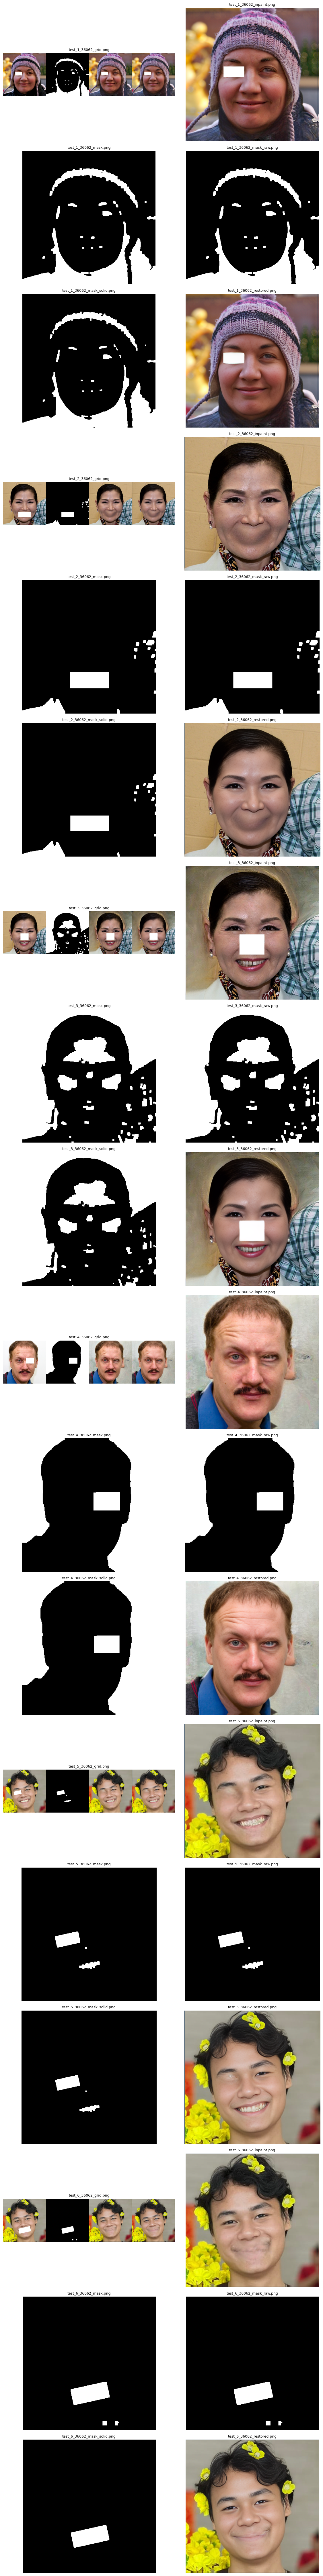

In [47]:
import glob, cv2, math
import matplotlib.pyplot as plt
import os

OUT_DIR = '/kaggle/working/outputs'
paths = []
for ext in ('*.png','*.jpg','*.jpeg','*.webp','*.bmp'):
    paths.extend(glob.glob(os.path.join(OUT_DIR, ext)))
paths = sorted(paths)

cols = 2
rows = math.ceil(len(paths) / cols)
plt.figure(figsize=(12, rows*5))
for i, p in enumerate(paths, 1):
    img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    plt.subplot(rows, cols, i)
    plt.imshow(img); plt.title(os.path.basename(p), fontsize=9); plt.axis('off')
plt.tight_layout(); plt.show()